# Import Data

In [62]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# Import data and observe shape and columns
chess_data_raw = pd.read_csv("data/games.csv")
print(chess_data_raw.shape)
print(chess_data_raw.columns)
chess_data_raw.head(10)

(20058, 16)
Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5
5,MsoDV9wj,False,1.504240e+12,1.504240e+12,5,draw,draw,10+0,trelynn17,1250,franklin14532,1002,e4 c5 Nf3 Qa5 a3,B27,Sicilian Defense: Mongoose Variation,4
6,qwU9rasv,True,1.504230e+12,1.504230e+12,33,resign,white,10+0,capa_jr,1520,daniel_likes_chess,1423,d4 d5 e4 dxe4 Nc3 Nf6 f3 exf3 Nxf3 Nc6 Bb5 a6 ...,D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10
7,RVN0N3VK,False,1.503680e+12,1.503680e+12,9,resign,black,15+30,daniel_likes_chess,1413,soultego,2108,e4 Nc6 d4 e5 d5 Nce7 c3 Ng6 b4,B00,Nimzowitsch Defense: Kennedy Variation | Link...,5
8,dwF3DJHO,True,1.503510e+12,1.503510e+12,66,resign,black,15+0,ehabfanri,1439,daniel_likes_chess,1392,e4 e5 Bc4 Nc6 Nf3 Nd4 d3 Nxf3+ Qxf3 Nf6 h3 Bc5...,C50,Italian Game: Schilling-Kostic Gambit,6
9,afoMwnLg,True,1.503440e+12,1.503440e+12,119,mate,white,10+0,daniel_likes_chess,1381,mirco25,1209,e4 d5 exd5 Qxd5 Nc3 Qe5+ Be2 Na6 d4 Qf5 Bxa6 b...,B01,Scandinavian Defense: Mieses-Kotroc Variation,4


# Clean data
- Remove IDs (main ID and player IDs)

In [64]:
chess_data = chess_data_raw.drop(columns=["id", "white_id", "black_id"])

# Drop all non-rated games for doing rating analysis
chess_data = chess_data[chess_data["rated"] == True]
chess_data["winner"] = chess_data["winner"].map({"black": -1, "draw": 0, "white": 1})

# Add column for game_rating. This is the average ELO of both players
chess_data["game_rating"] = (chess_data["white_rating"] + chess_data["black_rating"]) / 2

### Game ELO buckets
These will be used later on to demonstrate the differences in low, medium, and high ELO players

In [65]:
chess_data["rating_bucket"] = pd.cut(
    chess_data["game_rating"],
    bins=[0, 1200, 1800, 3000],
    labels=["low", "medium", "high"]
)

# Descriptive Statistics

In [66]:
print("Players of Black Ratings ---------------")
print("Mean:", chess_data["black_rating"].mean())
print("Median:", chess_data["black_rating"].median())
print()
print("Players of White Ratings ---------------")
print("Mean:", chess_data["white_rating"].mean())
print("Median:", chess_data["white_rating"].median())
print()
# Make array with every player (both black or white)
all_players = pd.concat([chess_data['white_rating'], chess_data['black_rating']], ignore_index=True)
print("All Player Ratings ---------------")
print("Mean:", all_players.mean())
print("Median:", all_players.median())
print()

print("Average number of turns")
print(chess_data['turns'].mean())

Players of Black Ratings ---------------
Mean: 1593.5031878675334
Median: 1573.0

Players of White Ratings ---------------
Mean: 1597.1020117610647
Median: 1577.0

All Player Ratings ---------------
Mean: 1595.302599814299
Median: 1575.0

Average number of turns
61.96255029402662


(array([ 278., 1409., 4351., 7539., 7618., 5888., 3320., 1480.,  396.,
          31.]),
 array([ 784. ,  967.8, 1151.6, 1335.4, 1519.2, 1703. , 1886.8, 2070.6,
        2254.4, 2438.2, 2622. ]),
 <BarContainer object of 10 artists>)

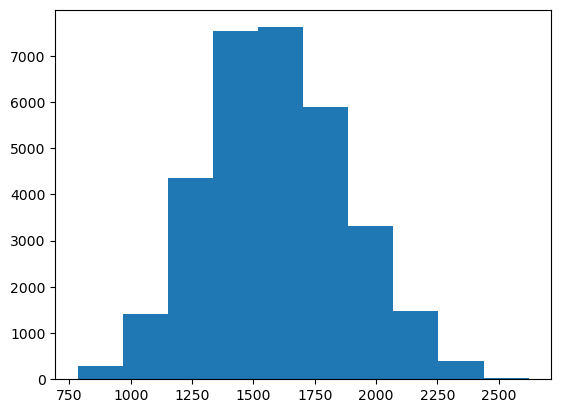

In [67]:
# Show ELOs of all players
plt.hist(all_players)

(array([  51.,  527., 1783., 3367., 3902., 3032., 2073., 1000.,  365.,
          55.]),
 array([ 816.5,  982.4, 1148.3, 1314.2, 1480.1, 1646. , 1811.9, 1977.8,
        2143.7, 2309.6, 2475.5]),
 <BarContainer object of 10 artists>)

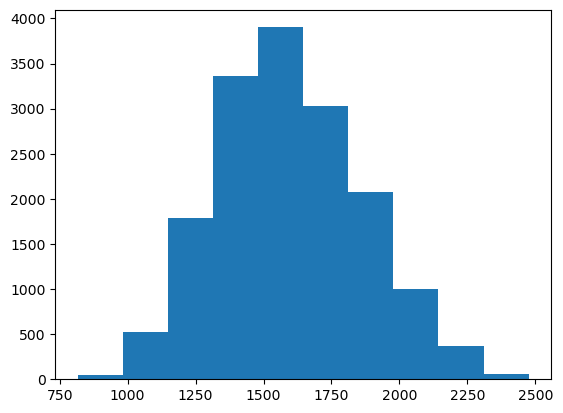

In [68]:
plt.hist(chess_data['game_rating'])

(array([3.456e+03, 7.287e+03, 3.594e+03, 1.404e+03, 3.530e+02, 4.800e+01,
        9.000e+00, 2.000e+00, 0.000e+00, 2.000e+00]),
 array([  1. ,  35.8,  70.6, 105.4, 140.2, 175. , 209.8, 244.6, 279.4,
        314.2, 349. ]),
 <BarContainer object of 10 artists>)

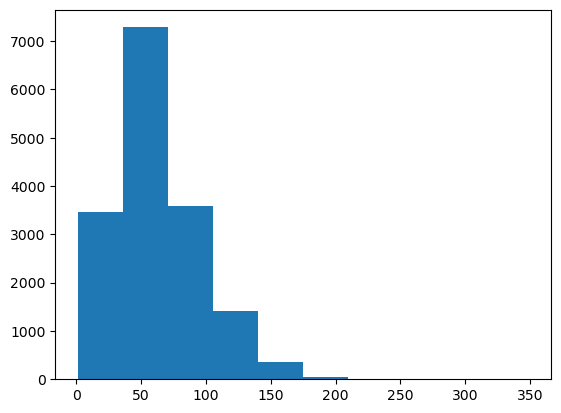

In [69]:
plt.hist(chess_data['turns'])

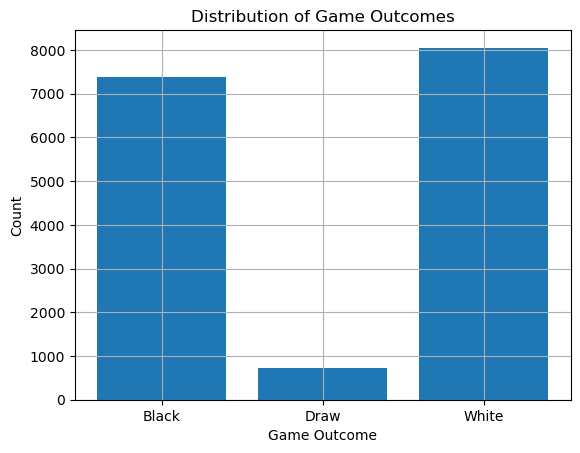

In [70]:
# Count occurrences of each outcome
counts = chess_data['winner'].value_counts().sort_index()

# Ensure order: Black (-1), Draw (0), White (1)
counts = counts.reindex([-1, 0, 1])

# Map labels
labels = ['Black', 'Draw', 'White']

# Plot
plt.figure()
plt.bar(labels, counts)

plt.xlabel('Game Outcome')
plt.ylabel('Count')
plt.title('Distribution of Game Outcomes')
plt.grid()

# Correlation

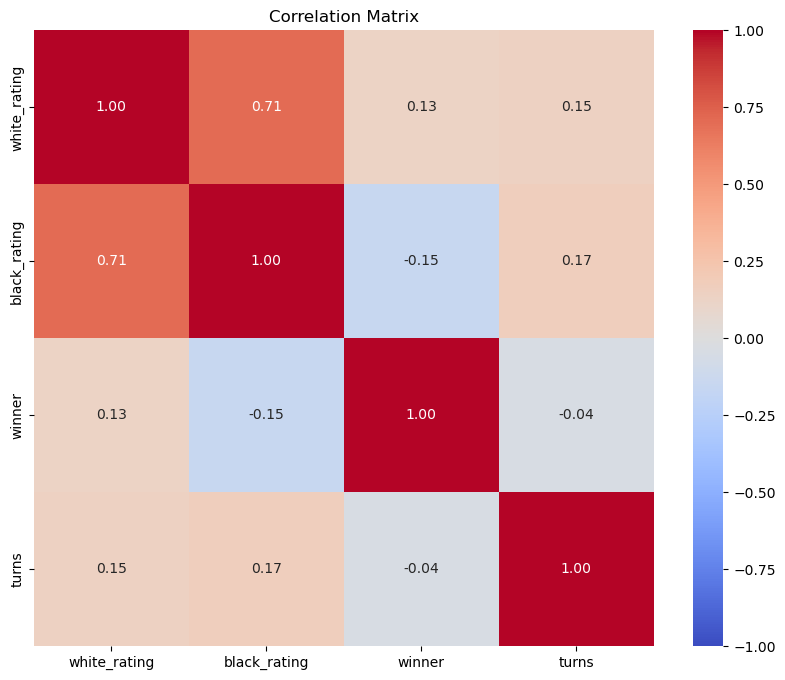

In [71]:
chess_corr_data = chess_data[["white_rating", "black_rating", "winner", "turns"]]

corr_matrix = chess_corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmax=1, vmin=-1)
plt.title("Correlation Matrix")
plt.show()

# Opening Evaluation

In [72]:
# Find the stats for each ECO
eco_stats = chess_data.groupby("opening_eco").agg(
    white_rating_mean=("white_rating", "mean"),
    white_rating_std=("white_rating", "std"),
    black_rating_mean=("black_rating", "mean"),
    black_rating_std=("black_rating", "std"),
    count=("opening_eco", "size")
)

In [73]:
most_popular = eco_stats.nlargest(20, "count")
least_popular = eco_stats[eco_stats["count"] == 1]

most_popular

,white_rating_mean,white_rating_std,black_rating_mean,black_rating_std,count
opening_eco,,,,,
A00,1436.684145,270.479128,1490.149813,293.035885,801
C00,1566.980743,260.836707,1547.447043,286.054734,727
D00,1528.164154,283.840973,1551.050251,286.225308,597
B01,1532.117547,289.958197,1526.860307,308.139414,587
C41,1533.804618,240.503144,1494.978686,225.083131,563
C20,1385.660448,206.730201,1401.283582,218.463329,536
A40,1585.581213,299.697182,1547.181996,280.630711,511
B20,1538.226293,262.212967,1606.303879,270.690590,464
B00,1538.214286,271.199328,1476.448052,275.762914,462


# Stockfish analysis
- Stockfish is an open source chess engine
- It helps analyze boards, find the best move, and rate moves

## Install
- If on mac, in the terminal run `brew install stockfish`
- If on windows
    - Go to the official Stockfish website
	- Download the Windows (64-bit) version (usually a .zip)
    - Unzip
    - OR install with conda `conda install -c conda-forge stockfish` (I couldn't get this to work)

Then:
- For python `pip install stockfish`
- I couldn't find a way to install with Conda

# Questions
1. Can stockfish reliably predict the winner of the game from the first 20 moves?
2. ...

In [74]:
# ------ Question 1 ------
import chess

# Find all games that have more than 20 moves
stockfish_games = chess_data[chess_data["turns"] > 20].sample(n=10, random_state=42)


board = chess.Board()
uci_moves_column = []

for row in stockfish_games.itertuples():
    uci_moves = []
    # Convert SAN to UCI (which is what stockfish expects)
    for san in row.moves.split(" "):
        move = board.parse_san(san)   # convert SAN to a legal move object
        uci_moves.append(move.uci())  # convert move object to UCI string
        board.push(move)

    uci_moves_column.append(uci_moves)
    board.reset()

stockfish_games["moves"] = uci_moves_column

In [75]:
from accuracy import get_accuracies

acc_df = get_accuracies(stockfish_games["moves"])
acc_df

,white_accuracy,black_accuracy,overall_accuracy,white_avg_cpl,black_avg_cpl
0,64.90,67.23,66.05,9.6,8.8
1,0.00,0.00,0.00,2501.4,2501.4
2,0.00,0.00,0.00,333.3,328.3
3,57.09,59.74,58.39,12.3,11.4
4,0.00,0.00,0.00,321.5,309.8
5,0.00,0.00,0.00,673.9,643.4
6,0.00,0.00,0.00,2501.4,2501.4
7,0.00,0.00,0.00,317.2,297.8
8,0.00,0.00,0.00,262.6,263.5
9,18.83,17.68,18.25,35.5,36.7


In [76]:
# Work on later
from stockfish import Stockfish

stockfish = Stockfish(path="/opt/homebrew/bin/stockfish")
stockfish.set_depth(15) # Depth strikes a balance between speed and accuracy
eval_stats = []

for row in stockfish_games.itertuples():
    # Get the eval at 20 and the previous 3 turns and add to stats
    pass


# Ensure Stockfish shuts down nicely
stockfish.send_quit_command()
# print(eval_stats)
# stockfish_games["eval_at_20"] = eval_stats

In [77]:
# Are low ELO players able to see mate better than higher ELO players?

# Algorithm flow
# 1. Go through games move by move
# 2. If computer says 'mate' on eval...
# 3. We see whether they won
# If they did win, how many more moves did it take?




# Heatmaps of Chess Board
- Higher signal means the square is moved to more often
- Gives an idea of how the game is played (in a general sense, with no respect to the pieces)

In [98]:
def iterate_heatmap_from_moves(moves, board, heatmap):
    for san in moves:
        try:
            move = board.parse_san(san)
        except:
            break  # skip invalid games
        
        square = move.to_square
        
        # Convert square index → row, col
        row = 7 - chess.square_rank(square)
        col = chess.square_file(square)
        
        heatmap[row, col] += 1

        board.push(move)

In [99]:
# Heatmap of chess board
stockfish_games = chess_data[chess_data["turns"] > 20]

# 8x8 board (rank 8 at top, rank 1 at bottom)
opening_heatmap = np.zeros((8, 8))
mid_game_heatmap = np.zeros((8, 8))
end_game_heatmap = np.zeros((8, 8))

for moves in stockfish_games["moves"]:
    board = chess.Board()
    move_list = moves.split(" ")

    if len(move_list) > 30:
        opening = move_list[:10]
        mid_game = move_list[10:30]
        end_game = move_list[30:]
    else:
        opening = move_list[:10]
        mid_game = []
        end_game = move_list[10:]

    iterate_heatmap_from_moves(opening, board, opening_heatmap)
    iterate_heatmap_from_moves(mid_game, board, mid_game_heatmap)
    iterate_heatmap_from_moves(end_game, board, end_game_heatmap)


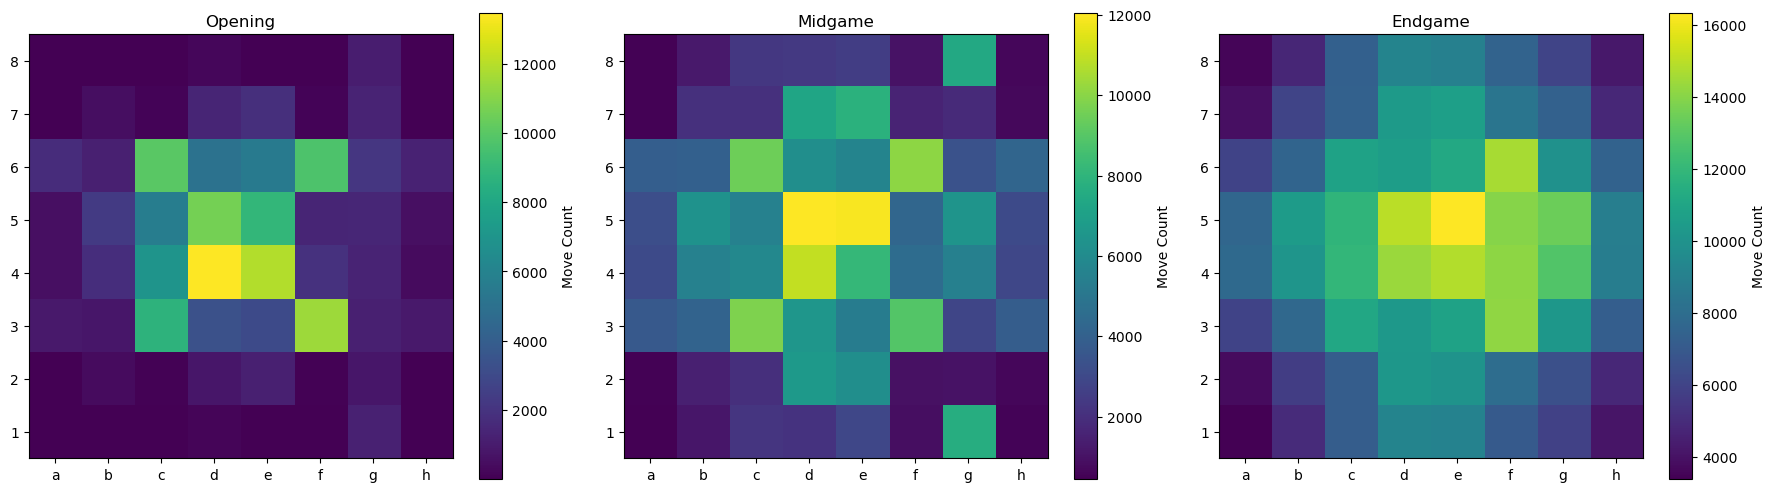

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

heatmaps = [opening_heatmap, mid_game_heatmap, end_game_heatmap]
titles = ["Opening", "Midgame", "Endgame"]

for ax, data, title in zip(axes, heatmaps, titles):
    im = ax.imshow(data)  # no shared vmin/vmax → independent scaling
    
    ax.set_xticks(range(8))
    ax.set_xticklabels(['a','b','c','d','e','f','g','h'])
    
    ax.set_yticks(range(8))
    ax.set_yticklabels(['8','7','6','5','4','3','2','1'])
    
    ax.set_title(title)
    
    # Individual colorbar per subplot
    plt.colorbar(im, ax=ax, label="Move Count")

plt.tight_layout()
plt.show()

# More Questions
- How frequently is each piece used?
- Which pieces are most commonly found in the end game?
- Piece to victory correlation